<a href="https://colab.research.google.com/github/ancestor9/2026_Spring_Application_Programming/blob/main/week4/io_Core_tools_for_working_with_streams.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%writefile myfile.txt

Hello this is a text file
this is the second line
this is the third line

Overwriting myfile.txt


# Text I/O

In [ ]:
f = open("myfile.txt", "r", encoding="utf-8")
f

<_io.TextIOWrapper name='myfile.txt' mode='r' encoding='utf-8'>

In [ ]:
print(f.read())


Hello this is a text file
this is the second line
this is the third line



In [ ]:
print(f.read())

In [ ]:
import io

f = io.StringIO("some initial text data")
f

In [ ]:
print(f.read())

some initial text data


# with ~ 구문의 사용법

In [ ]:
import os

# 1. 테스트용 파일 생성
with open("test.txt", "w") as f:
    f.write("test")

handles = []
try:
    # 2. 파일을 닫지 않고 무한정 열기 (시스템 한계 도달 시 에러 발생)
    for i in range(1000):
        handles.append(open("test.txt"))
        if i % 100 == 0: print(f"{i}개 오픈 중...")
except OSError as e:
    # 3. "Too many open files" 에러 확인
    print(f"\n[오류 발생] 파일을 너무 많이 열었습니다: {e}")
finally:
    # 4. 정리
    for h in handles: h.close()
    os.remove("test.txt")

0개 오픈 중...
100개 오픈 중...
200개 오픈 중...
300개 오픈 중...
400개 오픈 중...
500개 오픈 중...
600개 오픈 중...
700개 오픈 중...
800개 오픈 중...
900개 오픈 중...


In [ ]:
import os

# 1. 파일 쓰기 (with가 끝나면 자동으로 닫힘)
with open("test.txt", "w", encoding="utf-8") as f:
    f.write("안전한 파일 처리")

# 2. 파일 읽기 (별도의 close() 호출 불필요)
with open("test.txt", "r", encoding="utf-8") as f:
    print(f"읽은 내용: {f.read()}")

# 3. 정리 (파일 삭제)
os.remove("test.txt")

읽은 내용: 안전한 파일 처리


위의 예시에서 볼 수 있듯이, `open()`으로 파일을 열고 `close()`를 명시적으로 호출하지 않으면 시스템 리소스가 고갈되어 `OSError`와 같은 예외가 발생할 수 있습니다. 이를 방지하기 위한 가장 좋은 방법은 `with open(...)` 문을 사용하는 것입니다. `with` 문은 블록이 끝날 때 자동으로 파일을 닫아줍니다.

# Binary I/O

In [ ]:
url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSqtKG7XRBdNq1pjIhirRyqJDBatoJhKT-FBYY9ebpz63ZLBIEWhr2ddtOmT5d8iFY6v6kT7Avu0S-iDdbOoBosyKPzx_DV_yKa7XFJPuCF&s=10"

In [ ]:
import requests

try:
    response = requests.get(url)
    response.raise_for_status()  # Raise an exception for HTTP errors

    # Determine filename from URL or use a default
    filename = "downloaded_image.jpg" # Assuming it's an image based on the URL variable name

    with open(filename, "wb") as f:
        f.write(response.content)
    print(f"Image successfully downloaded and saved as '{filename}'")
except requests.exceptions.RequestException as e:
    print(f"Error downloading image: {e}")


Image successfully downloaded and saved as 'downloaded_image.jpg'


In [ ]:
f = open("downloaded_image.jpg", "rb")
print(f.read())

b'RIFFRa\x00\x00WEBPVP8 Fa\x00\x000\xbf\x01\x9d\x01*/\x02\x7f\x01>E\x1e\x8cE"\xa1\xa1\x12\xc8\x9d\xb0(\x04D\xb3\xb6\xe0\x06\xa0\x88b:9\xd6\xbdq\xc4#\x8a\xffC\xff_\xbcmd\xaa\x96\xfdv\xf3\x92\xf5\xdf\xfe\xe7\x94\xbf\xd6\xf7\x847\x8e\x11d\xff2\x1eE\xf4\x80a\xde\xe0FO\xea\xbf\xf5=\x9d1\xac\xe6A\xe6=x\xfek\xf6O\xf4=D?\x8d\xcd\x9f\xa6\x7f\xad\xe6o\xf4O\xd0Y\xca\xff\x13\xc8?\xa1\x9a\x1ax\xf4F\xd3S4\xc9\xfdW\xa0\xff\xf8~Z\xfey\xfbi\xf0+\xfaW\xfe\xf7\xb3\x8f\xf9\x7f\xb8~\xab\xbe\xb4\xe9\xc0\xf6\x97\xfa\xcb\xff\xff\xd54\xcf\xcfXq\xcdU\xfc\xfe\xd2Za{\x19[\x94_\x05\x9d\xff\xe2\x96\xb6\x1e\xb7\'+\xdeFV=w\xb5\x1f:%\x980\xff7P\xe6\xa1\xf6\\I\xfa\xeesw\x93T\xbf51,\xee\xbd\x10\x99+]\x1f\x92\x116\x9c9\x10\xba\xfc J6?(\x88\x0emx4\x9d\xaf)\x00\x9d2C"k\xcc\xaa\x88\xdf\xc1\xcf\xc7\xfd<\xf5\xee\xbc\x89h\xc9\xf3\xe6B\xbe\xa8\xb4W*|\x1a\x1b\xd4\x87\x90\xb2\xea\xe5\xd14\xe5v\xe6\x16\xd74$\xd5O\x9e^\xefr\x97\xb3\x88\x8e\xa6\xb4"\x06\xc8h,\xc8\x04r\x1e\xb0Lt\xea\x8d+\xd2\x9ay\x86\x94\\6\xba\x86\xc5\xde\xac\xa5+\x

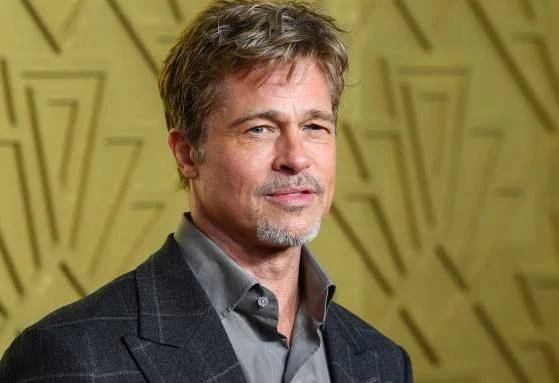

In [ ]:
from IPython.display import Image
Image(filename='downloaded_image.jpg')

In [ ]:
f = io.BytesIO(b"some initial binary data: \x00\x01")
f

# Raw I/O